In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import scipy
import yaml

import cv2
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from brisque import BRISQUE
from skvideo.measure import niqe
from pypiqe import piqe
from mahotas.features import zernike_moments
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import datasets, transforms
import segmentation_models_pytorch as smp

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

In [7]:
# Hyperparameters and paths
DEVICE_ID = 0
BATCH_SIZE = 128
IMAGE_SIZE = 320

DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
SEGMENTATION_NAME = "deeplabv3plus"
SEGMENTATION_ENCODER = "resnext50_32x4d"
SEGMENTATION_WEIGHTS = r"/home/c/choton/beemachine/codes/everyday_test/Oct25_25/deeplabv3_test/lightning_logs/version_1/checkpoints/epoch=199-step=37400.ckpt"

In [8]:
# Create SIFT and ORB detectors once
sift = cv2.SIFT_create()
orb = cv2.ORB_create()
bri_obj = BRISQUE(url=False)

def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

def compute_sift_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_orb_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_hu_moments(mask):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

def compute_zernike_moments(mask, degree=8):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(image, Image.Image):
        image = np.asarray(image)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

def extract_all_features(image, mask):
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3
    full_mask = mask > 0

    head_feats = extract_combined_features(image, head_mask)
    thorax_feats = extract_combined_features(image, thorax_mask)
    abdomen_feats = extract_combined_features(image, abdomen_mask)
    body_feats = extract_combined_features(image, full_mask)

    # Ratios
    area_sum = head_feats["area"] + thorax_feats["area"] + abdomen_feats["area"]
    ratios = {
        "head_to_thorax_area": head_feats["area"] / (thorax_feats["area"] + 1e-6),
        "thorax_to_abdomen_area": thorax_feats["area"] / (abdomen_feats["area"] + 1e-6),
        "head_to_total_area": head_feats["area"] / (area_sum + 1e-6),
        "thorax_to_total_area": thorax_feats["area"] / (area_sum + 1e-6),
        "abdomen_to_total_area": abdomen_feats["area"] / (area_sum + 1e-6),
    }

    record = {}
    record.update({f"head_{k}": v for k, v in head_feats.items()})
    record.update({f"thorax_{k}": v for k, v in thorax_feats.items()})
    record.update({f"abdomen_{k}": v for k, v in abdomen_feats.items()})
    record.update({f"full_{k}": v for k, v in body_feats.items()})
    record.update(ratios)
    return record

In [9]:
# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):    
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = 4 # head, thorax, abdomen, background
            ).to(f"cuda:{DEVICE_ID}")
    # checkpoint_path = r"/home/c/choton/beemachine/codes/everyday_test/oct1_25/segmentation_models/lightning_logs/fpn/lightning_logs/version_0/checkpoints/epoch=199-step=37400.ckpt"
    checkpoint = torch.load(checkpoint_path, map_location=rf"cuda:{DEVICE_ID}")

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}

        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    # model.to(f"cuda:{DEVICE_ID}")
    return model

#  Segmentation prediction
def predict_mask(model, image_tensor):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(f"cuda:{DEVICE_ID}")
        output = model(image_tensor.unsqueeze(0))
        if isinstance(output, dict):  # handle SMP model dict outputs
            output = output['out']
        probs = torch.softmax(output, dim=1)
        mask = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
    return mask  # (H, W) integer mask

# Visualize prediction
def visualize(**images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([]), plt.yticks([])
        plt.title(" ".join(name.split("_")).title(), fontsize=14)

        if name == "image":
            # Handle CHW → HWC
            img = np.asarray(image)
            if img.ndim == 3 and img.shape[0] == 3:
                img = img.transpose(1, 2, 0)
            # Normalize to 0-1 if needed
            if img.max() > 1.0:
                img = img / 255.0
            plt.imshow(img)
            continue

        # ———————— MASK PLOTTING (supports unlimited classes) ————————
        mask = np.asarray(image).squeeze()  # HxW
        unique_vals = np.unique(mask)
        
        # Choose a colormap with many distinct colors
        base_cmap = plt.get_cmap("turbo")        # 256 beautiful distinct colors
        # Or: "nipy_spectral", "hsv", "jet", "gist_ncar"

        # Make it fully discrete
        max_val = int(mask.max())
        bounds = np.arange(-0.5, max_val + 1.5, 1)   # one bin per integer class
        norm = BoundaryNorm(bounds, base_cmap.N)
        
        im = plt.imshow(mask, cmap=base_cmap, norm=norm, interpolation='nearest')

        # ———————— LEGEND: exact matching colors ————————
        legend_patches = []
        for val in sorted(unique_vals):
            if val >= len(labels):
                label_name = f"Class {int(val)} (unknown)"
                color = 'lightgray'
            else:
                label_name = labels[int(val)]
                color = base_cmap(norm(val))  # exact color used in image
            
            legend_patches.append(
                Patch(color=color, label=label_name)
            )

        plt.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.0,
            fontsize=10,
            title="Classes",
            title_fontsize=12
        )

    plt.tight_layout()
    plt.show()

In [10]:
segmentation_model = load_segmentation(
            name=SEGMENTATION_NAME, 
            encoder_name=SEGMENTATION_ENCODER, 
            checkpoint_path=SEGMENTATION_WEIGHTS
        )
transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

In [11]:
train_imgs_path = os.path.join(DATA_DIR, 'train', 'aug_images')
val_imgs_path = os.path.join(DATA_DIR, 'valid', 'images')
test_imgs_path = os.path.join(DATA_DIR, 'test', 'images')
train_images = os.listdir(train_imgs_path)
val_images = os.listdir(val_imgs_path)
test_images = os.listdir(test_imgs_path)

In [12]:
yaml_path = os.path.join(DATA_DIR, 'data.yaml')
with open(yaml_path, 'r') as file:
    # Use safe_load for security, as it prevents arbitrary code execution
    config = yaml.safe_load(file)
print(config)
labels = config['names']
if 'background' not in labels:
    labels.insert(0, 'background')
print(labels)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['abdomen', 'head', 'thorax'], 'roboflow': {'workspace': 'test-f3zdy', 'project': 'beemachine-aqnj1', 'version': 10, 'license': 'MIT', 'url': 'https://universe.roboflow.com/test-f3zdy/beemachine-aqnj1/dataset/10'}}
['background', 'abdomen', 'head', 'thorax']


original image size: (381, 428) mask shape: (320, 320) class_ids: [0 1 2 3]
feature length 937
{'head_area': np.float32(2691.0), 'head_perimeter': np.float32(266.59293), 'head_aspect_ratio': np.float32(1.1828339), 'head_extent': np.float32(0.5425403), 'head_solidity': np.float32(0.74937344), 'head_eccentricity': np.float32(0.53409064), 'head_orientation': np.float32(-0.74835765), 'head_circularity': np.float32(0.47580206), 'head_elongation': np.float32(0.15457278), 'head_compactness': np.float32(2.1017144), 'head_sift_ds1': np.float32(15.833333), 'head_sift_ds2': np.float32(17.666666), 'head_sift_ds3': np.float32(10.5), 'head_sift_ds4': np.float32(11.666667), 'head_sift_ds5': np.float32(30.88889), 'head_sift_ds6': np.float32(9.666667), 'head_sift_ds7': np.float32(10.166667), 'head_sift_ds8': np.float32(10.388889), 'head_sift_ds9': np.float32(53.555557), 'head_sift_ds10': np.float32(33.5), 'head_sift_ds11': np.float32(14.777778), 'head_sift_ds12': np.float32(11.944445), 'head_sift_ds13'

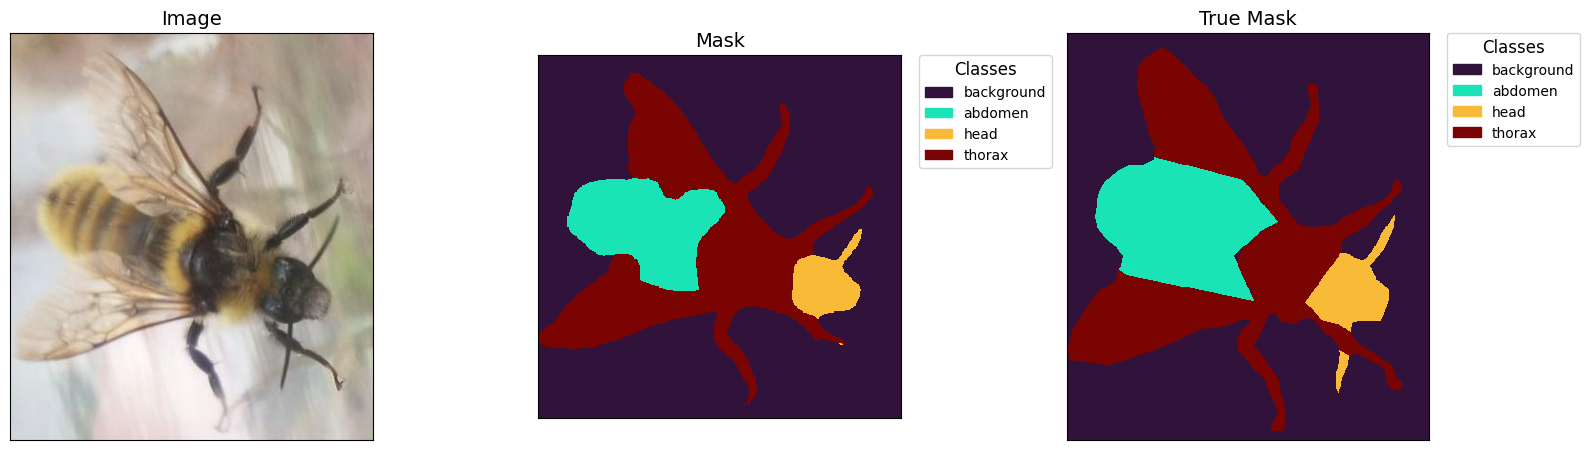

In [13]:
# Get a sample image
sample_image = val_images[0]
sample_img_path = os.path.join(val_imgs_path, sample_image)
sample_pil = Image.open(sample_img_path)
sample_img_tensor = transform(sample_pil).to(f"cuda:{DEVICE_ID}")
# plt.imshow(sample_pil)

# True mask
base = os.path.splitext(sample_image)[0]
mask_path = os.path.join(DATA_DIR, 'valid', 'masks', base + "_m.png")
true_mask = Image.open(mask_path).convert("L")

# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=sample_img_tensor)
features = extract_all_features(sample_img_tensor, mask)

# Print outputs
print(f'original image size: {sample_pil.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))

print('feature length', len(features))
print(features)
visualize(image=sample_pil, mask=mask, true_mask=true_mask)

original image size: (1250, 1261) mask shape: (320, 320) class_ids: [0 1 2 3]
feature length 937
{'head_area': np.float32(4349.0), 'head_perimeter': np.float32(427.32086), 'head_aspect_ratio': np.float32(1.8283664), 'head_extent': np.float32(0.5648052), 'head_solidity': np.float32(0.78943545), 'head_eccentricity': np.float32(0.83717424), 'head_orientation': np.float32(1.2253039), 'head_circularity': np.float32(0.29928923), 'head_elongation': np.float32(0.4530637), 'head_compactness': np.float32(3.3412495), 'head_sift_ds1': np.float32(28.0), 'head_sift_ds2': np.float32(47.366665), 'head_sift_ds3': np.float32(12.966666), 'head_sift_ds4': np.float32(9.933333), 'head_sift_ds5': np.float32(17.433332), 'head_sift_ds6': np.float32(10.266666), 'head_sift_ds7': np.float32(3.0333333), 'head_sift_ds8': np.float32(3.5666666), 'head_sift_ds9': np.float32(78.03333), 'head_sift_ds10': np.float32(47.733334), 'head_sift_ds11': np.float32(12.9), 'head_sift_ds12': np.float32(10.866667), 'head_sift_ds13':

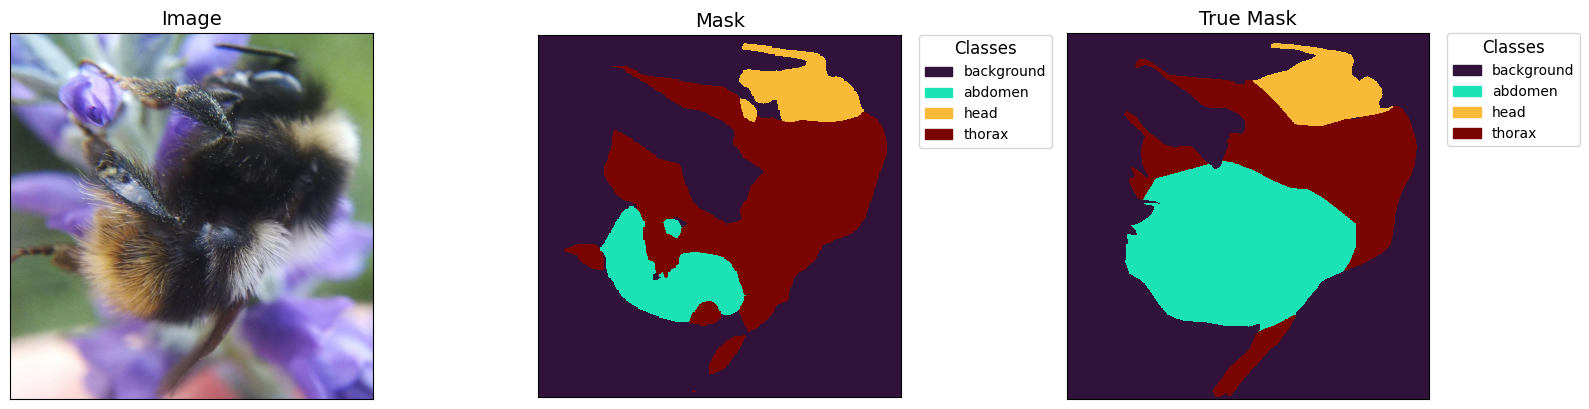

In [14]:
# Get a sample image
sample_image = val_images[77]
sample_img_path = os.path.join(val_imgs_path, sample_image)
sample_pil = Image.open(sample_img_path)
sample_img_tensor = transform(sample_pil).to(f"cuda:{DEVICE_ID}")
# plt.imshow(sample_pil)

# True mask
base = os.path.splitext(sample_image)[0]
mask_path = os.path.join(DATA_DIR, 'valid', 'masks', base + "_m.png")
true_mask = Image.open(mask_path).convert("L")

# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=sample_img_tensor)
features = extract_all_features(sample_img_tensor, mask)

# Print outputs
print(f'original image size: {sample_pil.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))

print('feature length', len(features))
print(features)
visualize(image=sample_pil, mask=mask, true_mask=true_mask)

original image size: (571, 570) mask shape: (320, 320) class_ids: [0 1 2 3]
feature length 937
{'head_area': np.float32(4.0), 'head_perimeter': np.float32(2.0), 'head_aspect_ratio': np.float32(0.0), 'head_extent': np.float32(1.0), 'head_solidity': np.float32(1.0), 'head_eccentricity': np.float32(1.0), 'head_orientation': np.float32(0.0), 'head_circularity': np.float32(12.566371), 'head_elongation': np.float32(1.0), 'head_compactness': np.float32(0.07957747), 'head_sift_ds1': np.float32(28.318182), 'head_sift_ds2': np.float32(34.0), 'head_sift_ds3': np.float32(25.09091), 'head_sift_ds4': np.float32(26.954546), 'head_sift_ds5': np.float32(17.954546), 'head_sift_ds6': np.float32(11.681818), 'head_sift_ds7': np.float32(10.863636), 'head_sift_ds8': np.float32(17.227272), 'head_sift_ds9': np.float32(42.545456), 'head_sift_ds10': np.float32(25.454546), 'head_sift_ds11': np.float32(23.136364), 'head_sift_ds12': np.float32(38.227272), 'head_sift_ds13': np.float32(25.454546), 'head_sift_ds14': n

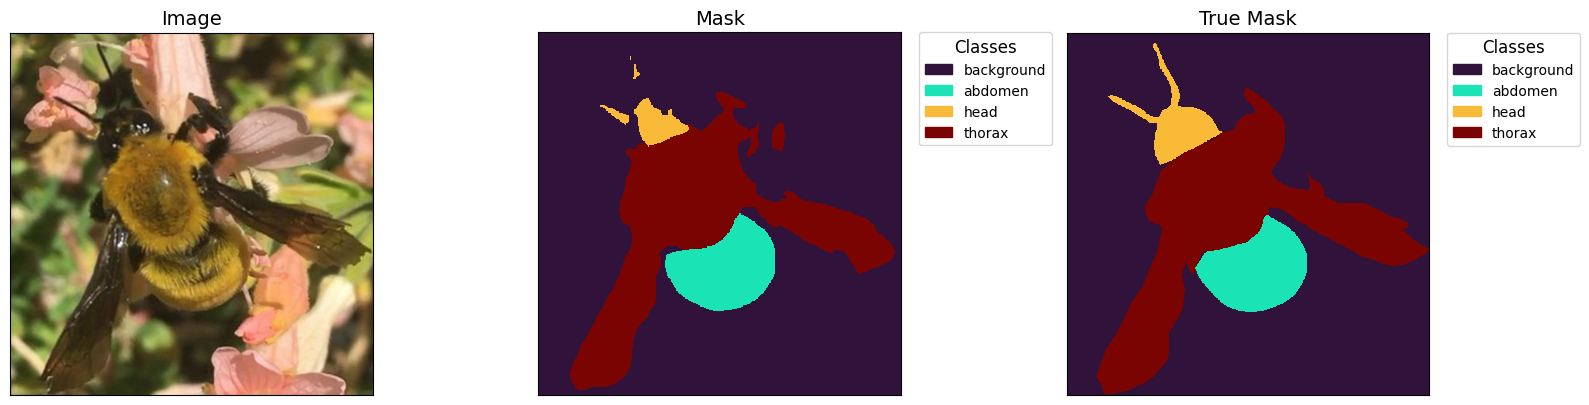

In [16]:
# Get a sample image
sample_image = val_images[786]
sample_img_path = os.path.join(val_imgs_path, sample_image)
sample_pil = Image.open(sample_img_path)
sample_img_tensor = transform(sample_pil).to(f"cuda:{DEVICE_ID}")
# plt.imshow(sample_pil)

# True mask
base = os.path.splitext(sample_image)[0]
mask_path = os.path.join(DATA_DIR, 'valid', 'masks', base + "_m.png")
true_mask = Image.open(mask_path).convert("L")

# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=sample_img_tensor)
features = extract_all_features(sample_img_tensor, mask)

# Print outputs
print(f'original image size: {sample_pil.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))

print('feature length', len(features))
print(features)
visualize(image=sample_pil, mask=mask, true_mask=true_mask)

In [17]:
# --- Replace NaNs within each species group ---
def fill_by_class_mean(df, class_col="species"):
    df = df.replace(0, np.nan)
    df = df.dropna(axis=1, how='all')
    df_numeric = df.select_dtypes(include=[np.number])
    # Fill NaNs in numeric columns using the class-wise mean
    df[df_numeric.columns] = df.groupby(class_col)[df_numeric.columns].transform(
        lambda x: x.fillna(x.mean())
    )
    # Step 2: fill any remaining NaNs globally (for columns that were all NaN in a class)
    df[df_numeric.columns] = df[df_numeric.columns].fillna(df[df_numeric.columns].mean())
    return df

In [18]:
def extract_features_for_dataset(dataset_images, dataset_path, output_csv):
    records = []
    print(f"Extracting shape features for {len(dataset_images)} images...")
    # x = 0
    for img in tqdm(dataset_images, desc="Extracting shape features"):
        # process image
        img_path = os.path.join(dataset_path, img)
        img_pil = Image.open(img_path)
        img_tensor = transform(img_pil).to(f"cuda:{DEVICE_ID}")

        # Predict mask and compute descriptors
        mask_pred = predict_mask(model=segmentation_model, image_tensor=img_tensor)
        features = extract_all_features(img_tensor, mask_pred)

        record = {"image": img}
        record.update(features)
        records.append(record)
        # if x == 5:
        #     break
        # x += 1

    # Make and save the dataframe
    df = pd.DataFrame(records)
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved shape features to: {output_csv}")
    return df

In [19]:
os.makedirs(r"./predicted_shape_features", exist_ok=True)
assert False, "Manual break"

AssertionError: Manual break

In [20]:
%%time
CSV_PATH = r"./predicted_shape_features/beemachine_partwhole_v5_train.csv"
df = extract_features_for_dataset(dataset_images=train_images, dataset_path=train_imgs_path, output_csv=CSV_PATH)
df

Extracting shape features for 34722 images...


Extracting shape features:   0%|          | 4/34722 [00:03<9:38:02,  1.00it/s]/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:114: RuntimeWarning: invalid value encountered in scalar divide
  return (np.sum(np.abs(x)) / size) ** 2 / (np.sum(x ** 2) / size)
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:124: RuntimeWarning: invalid value encountered in divide
  return squares_sum / ((filtered_values.shape))
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pypiqe/piqe.py:142: RuntimeWarning: invalid value encountered in divide
  ipImage = np.round(255 * (ipImage / np.max(ipImage)))
Extracting shape features: 100%|██████████| 34722/34722 [11:08:24<00:00,  1.16s/it]  


✅ Saved shape features to: ./predicted_shape_features/beemachine_partwhole_v5_train.csv
CPU times: user 21h 33min 29s, sys: 10min 51s, total: 21h 44min 20s
Wall time: 11h 9min 11s


,image,head_area,head_perimeter,head_aspect_ratio,head_extent,head_solidity,head_eccentricity,head_orientation,head_circularity,head_elongation,...,full_colorfulness,full_entropy,full_brisque,full_niqe,full_piqe,head_to_thorax_area,thorax_to_abdomen_area,head_to_total_area,thorax_to_total_area,abdomen_to_total_area
0,Bombus_distinguendus_GBIF_iNat_2573822774_2-jp...,3925.0,368.469086,1.107346,0.588015,0.772942,0.429514,-1.047061,0.363285,0.096940,...,0.183499,6.315095,58.424229,30.060743,43.244968,0.175741,2.572449e+00,0.112332,0.639192,0.248476
1,Bombus_bifarius_47362646_1_1_jpg.rf.bd7d10af8d...,865.0,129.497482,2.422290,0.706699,0.929109,0.910807,1.360611,0.648192,0.587168,...,0.165101,6.093960,94.437653,26.321207,87.514603,3.728448,2.882346e-02,0.094577,0.025366,0.880057
2,BBW_Bombus_vandykei_4734_549ccb25-aae0-45c5-b0...,3606.0,291.220337,1.522208,0.572381,0.898356,0.753943,-0.403188,0.534309,0.343060,...,0.102462,6.838093,62.844711,26.185120,62.423027,0.182814,1.251110e+00,0.092232,0.504514,0.403253
3,20DQ50CQ40DQG000G0DQ20TRQQYRKQTRSQZ0I0Z090TRXQ...,3153.0,337.261963,1.447305,0.404127,0.720850,0.722913,-0.321106,0.348337,0.309061,...,0.117597,7.333617,55.270817,26.862755,40.348625,0.133055,1.506580e+00,0.074051,0.556542,0.369407
4,BBW_Bombus_sitkensis_1695_537b7c71-eed0-4246-a...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.057040,4.078943,94.575607,26.222328,78.291664,0.000000,8.693681e-01,0.000000,0.465060,0.534940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34717,3L6LLZELIZTZ2RKH5RZH2R3ZIRYZMR2LQRLHMZVLMZOL2R...,4592.0,341.119843,1.934126,0.610720,0.932386,0.855968,-0.522298,0.495904,0.482970,...,0.131877,4.429813,105.598923,26.906782,71.055122,12.546448,3.660000e+08,0.926180,0.073820,0.000000
34718,Bombus_bellicosus_GBIF_iNat_3301959651_3-jpg_j...,407.0,77.455841,1.552611,0.807540,0.953162,0.764961,1.567008,0.852503,0.355924,...,0.101592,6.838377,72.695602,26.826027,66.476753,0.009678,3.504500e+03,0.009583,0.990135,0.000283
34719,BBB_Bombus_affinis_693-2_1_jpg.rf.a52439e8cf4f...,3522.0,343.178711,1.932117,0.523640,0.793422,0.855643,-1.305170,0.375802,0.482433,...,0.100466,7.331975,63.675842,27.308632,54.810070,1.170878,1.895161e-01,0.157218,0.134274,0.708508
34720,5HTHXHDH6H6ZMLAZILAZXLBZ7L9Z5L9Z7LBZ4L6ZQL1ZUH...,4846.0,659.204163,1.389889,0.277231,0.461392,0.694511,-0.874828,0.140137,0.280518,...,0.104730,5.774931,70.901054,27.967340,52.485935,1.836998,4.515577e-01,0.363650,0.197959,0.438391


In [21]:
%%time
CSV_PATH = r"./predicted_shape_features/beemachine_partwhole_v5_val.csv"
df = extract_features_for_dataset(dataset_images=val_images, dataset_path=val_imgs_path, output_csv=CSV_PATH)
df

Extracting shape features for 1158 images...


Extracting shape features:   1%|          | 7/1158 [00:06<16:50,  1.14it/s]/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:114: RuntimeWarning: invalid value encountered in scalar divide
  return (np.sum(np.abs(x)) / size) ** 2 / (np.sum(x ** 2) / size)
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:124: RuntimeWarning: invalid value encountered in divide
  return squares_sum / ((filtered_values.shape))
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pypiqe/piqe.py:142: RuntimeWarning: invalid value encountered in divide
  ipImage = np.round(255 * (ipImage / np.max(ipImage)))
Extracting shape features: 100%|██████████| 1158/1158 [15:50<00:00,  1.22it/s]


✅ Saved shape features to: ./predicted_shape_features/beemachine_partwhole_v5_val.csv
CPU times: user 45min 8s, sys: 19.1 s, total: 45min 27s
Wall time: 15min 51s


,image,head_area,head_perimeter,head_aspect_ratio,head_extent,head_solidity,head_eccentricity,head_orientation,head_circularity,head_elongation,...,full_colorfulness,full_entropy,full_brisque,full_niqe,full_piqe,head_to_thorax_area,thorax_to_abdomen_area,head_to_total_area,thorax_to_total_area,abdomen_to_total_area
0,BBW_Bombus_appositus_23855_e5f978d9-d6e7-4322-...,2691.0,266.592926,1.182834,0.542540,0.749373,0.534091,-0.748358,0.475802,0.154573,...,0.101216,5.619246,69.066902,27.150719,57.412891,0.121364,2.498648,0.079762,0.657211,0.263027
1,Bombus_lapidarius_iNat_12287097_1-jpg_jpg.rf.3...,2228.0,274.894440,1.649547,0.479759,0.702839,0.795291,-1.366018,0.370504,0.393773,...,0.117895,7.749644,46.430492,25.923859,40.443417,0.069111,2.498295,0.047034,0.680557,0.272409
2,0HGRDZIROZ7RFZXRULHZ9L0R3ZYLNLKROZRZ9LYLNLZZTZ...,6.0,4.000000,0.000000,1.000000,1.000000,1.000000,1.570796,4.712389,1.000000,...,0.050085,5.552472,37.561543,24.301844,45.667454,0.000199,143.156403,0.000197,0.992867,0.006936
3,Bombus_morio_GBIF_iNat_2603344712_9-jpg_jpg.rf...,3.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.570796,37.699112,1.000000,...,0.039111,4.828111,68.277153,26.799677,51.807255,0.000096,446.271423,0.000096,0.997669,0.002236
4,Bombus_pratorum_iNat_21415168_1-jpg_jpg.rf.0db...,1553.0,223.480225,1.598443,0.418598,0.725701,0.780137,-0.379662,0.390754,0.374391,...,0.116128,5.819035,43.120174,27.321804,40.620838,0.053329,11.588141,0.046795,0.877482,0.075722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,BBB_Bombus_affinis_1026-2_1_jpg.rf.055960b6e3a...,194.0,68.941124,2.936821,0.400826,0.818565,0.940243,0.796517,0.512926,0.659496,...,0.122360,5.430021,57.868698,25.719839,55.287193,0.006929,9.985022,0.006259,0.903278,0.090463
1154,5LVZXLBZHLHRMHYHEHZR9HRRNHHR2HAZ2H9Z2HAZ8LWZ8L...,43.0,23.071068,1.216195,0.767857,0.895833,0.569146,1.288721,1.015180,0.177764,...,0.096381,5.244606,83.178978,25.096195,62.978966,0.002464,1.947991,0.001625,0.659712,0.338663
1155,BBW_Bombus_flavifrons_1337_536808c9-deb0-4c8b-...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.153824,4.629021,71.354675,25.687166,56.654583,0.000000,0.259237,0.000000,0.205868,0.794132
1156,Bombus_alpinus_iNat_54101328_1-jpg_jpg.rf.38ff...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.156528,6.130732,66.974976,24.353470,51.735924,0.000000,0.771700,0.000000,0.435570,0.564430


In [22]:
%%time
CSV_PATH = r"./predicted_shape_features/beemachine_partwhole_v5_test.csv"
df = extract_features_for_dataset(dataset_images=test_images, dataset_path=test_imgs_path, output_csv=CSV_PATH)
df

Extracting shape features for 771 images...


Extracting shape features:   0%|          | 2/771 [00:01<12:01,  1.07it/s]/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:114: RuntimeWarning: invalid value encountered in scalar divide
  return (np.sum(np.abs(x)) / size) ** 2 / (np.sum(x ** 2) / size)
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:124: RuntimeWarning: invalid value encountered in divide
  return squares_sum / ((filtered_values.shape))
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pypiqe/piqe.py:142: RuntimeWarning: invalid value encountered in divide
  ipImage = np.round(255 * (ipImage / np.max(ipImage)))
Extracting shape features: 100%|██████████| 771/771 [11:12<00:00,  1.15it/s]


✅ Saved shape features to: ./predicted_shape_features/beemachine_partwhole_v5_test.csv
CPU times: user 30min 25s, sys: 15.1 s, total: 30min 40s
Wall time: 11min 13s


,image,head_area,head_perimeter,head_aspect_ratio,head_extent,head_solidity,head_eccentricity,head_orientation,head_circularity,head_elongation,...,full_colorfulness,full_entropy,full_brisque,full_niqe,full_piqe,head_to_thorax_area,thorax_to_abdomen_area,head_to_total_area,thorax_to_total_area,abdomen_to_total_area
0,Bombus_robustus_GBIF_iNat_2814215056_7-jpg_jpg...,4365.0,472.552338,1.555812,0.513529,0.719703,0.766075,-0.219010,0.245637,0.357249,...,0.114707,6.028357,75.442657,30.042728,42.802139,0.269145,1.205710e+00,0.128254,0.476523,0.395222
1,5QV06QB0AQ6K8KAK8K1KLKVK7KAKUQLSXK2K5QB0UQ305K...,2662.0,485.232544,1.596086,0.210635,0.392394,0.779395,-0.064378,0.142075,0.373467,...,0.132920,7.412472,39.598804,29.143333,43.921082,0.119646,1.230382e+00,0.061916,0.517491,0.420594
2,60CQ70CQ6000E0FRQQH0E000IQ3R20FRQQTR20L090YRE0...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.080996,7.327576,40.433826,27.288603,46.785576,0.000000,1.218689e+00,0.000000,0.549283,0.450717
3,BBW_Bombus_appositus_28231_846be2d2-b3b3-4947-...,284.0,112.817284,7.781055,0.186842,0.818444,0.991707,0.730252,0.280399,0.871483,...,0.088179,5.059411,95.008362,26.515469,78.266045,20.285713,1.750000e+00,0.928105,0.045752,0.026144
4,Bombus_hortulanus_GBIF_iNat_2028461117_1-jpg_j...,3064.0,327.078217,1.505420,0.409079,0.636609,0.747496,0.491177,0.359911,0.335733,...,0.125349,5.245336,78.595718,26.242447,68.749222,0.130511,7.389676e+00,0.103102,0.789993,0.106905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,Bombus_medius_GBIF_iNat_1990632513_4-jpg_jpg.r...,28.0,18.485281,1.674305,0.666667,0.965517,0.802046,0.801719,1.029712,0.402737,...,0.162502,6.514753,58.078724,28.043051,55.338024,0.000721,1.940449e+04,0.000721,0.999228,0.000051
767,1KMKDKXKUKUQT0VQHS6QRS2QRSUQAKHKUK4Q9KSKT01QLS...,4172.0,380.605133,1.270588,0.585297,0.793156,0.616906,-0.263590,0.361914,0.212963,...,0.098404,5.520992,60.361370,24.775185,55.795444,0.165680,1.573813e+02,0.141361,0.853217,0.005421
768,BBW_Bombus_appositus_44103_4ece66ab-25be-459e-...,9531.0,687.009216,1.227939,0.405730,0.617453,0.580342,0.356568,0.253760,0.185627,...,0.054519,4.041050,78.808807,25.494541,63.796978,0.707888,1.346400e+10,0.414481,0.585519,0.000000
769,AL0ZTLQZNL5RFZSRTZKRTZKRTZQRJZ7RYZRZYZ7ROZFLOZ...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.128302,6.471976,59.398685,25.604660,53.212410,0.000000,1.012232e+00,0.000000,0.503040,0.496960
